In [8]:
import sys 
sys.path.append('..')

In [9]:

import geopandas as gpd
import rioxarray
import xarray as xr
from geocube.api.core import make_geocube
import pandas as pd 
from pathlib import Path


In [13]:
scene = "20230809_20230812"
scene_name = f'LC08_L2SP_013032_{scene}_02_T1'
neighborhoods = '../data/raw/2020_Neighborhood_Tabulation_Areas_(NTAs)_20260610.geojson'
gdf_neigbhorhood = gpd.read_file(neighborhoods)


In [32]:
temperature_file = '../data/raw/' + scene_name + '/' + scene_name + '_ST_B10.TIF'
qa_file =  '../data/raw/' + scene_name + '/' + scene_name + '_QA_PIXEL.TIF'

green_file = '../data/raw/' + scene_name + '/' + scene_name + '_SR_B3.TIF'
red_file = '../data/raw/' + scene_name + '/' + scene_name + '_SR_B4.TIF'
nir_file = '../data/raw/' + scene_name + '/' + scene_name + '_SR_B5.TIF'
swir_file = '../data/raw/' + scene_name + '/' + scene_name + '_SR_B6.TIF'

In [33]:
ds_temperature = rioxarray.open_rasterio(temperature_file, masked=True)

qa = rioxarray.open_rasterio(qa_file, masked=False)
red_band = rioxarray.open_rasterio(red_file, masked=True) * 0.0000275 - 0.2
nir_band = rioxarray.open_rasterio(nir_file, masked=True) * 0.0000275 - 0.2
green_band =rioxarray.open_rasterio(green_file, masked=True) * 0.0000275 - 0.2
swir_band =rioxarray.open_rasterio(swir_file, masked=True) * 0.0000275 - 0.2

# Bit 3 = cloud, Bit 4 = cloud shadow --> remove all clouds from temperature
qa_int16 = qa.data.astype('int16')
cloud_mask = (qa_int16 & 0b00001000) | (qa_int16 & 0b00010000)
ds_temperature_masked = ds_temperature.where(cloud_mask == 0)


# compute temperature (C) layer
ds_temperature_proj = ds_temperature_masked.rio.reproject("EPSG:4326") # same as gdfs

# Clip the raster to the shape -> .geometry act as a mask
lst_raw = ds_temperature_proj.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

# Apply scale factor → convert to Celsius
lst_celsius = lst_raw * 0.00341802 + 149.0 - 273.15
lst_celsius.name = "temperature_celsius"

In [16]:
## compute NDVI layer
ndvi = (nir_band - red_band) / (nir_band + red_band)
ndvi.name = "ndvi"

ndvi = ndvi.rio.reproject("EPSG:4326")
ndvi = ndvi.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

In [69]:
mndwi = (green_band - swir_band) / (green_band + swir_band)
mndwi.name = "mndwi"

mndwi = mndwi.rio.reproject("EPSG:4326")
mndwi = mndwi.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

In [34]:
ndmi = (nir_band-swir_band) / (nir_band + swir_band)
ndmi.name = "ndmi"

ndmi = ndmi.rio.reproject("EPSG:4326")
ndmi = ndmi.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

In [63]:
ndwi = (green_band - nir_band) / (green_band + nir_band)
ndwi.name = "ndwi"

ndwi = ndwi.rio.reproject("EPSG:4326")
ndwi = ndwi.rio.clip(gdf_neigbhorhood.geometry, gdf_neigbhorhood.crs)

In [66]:
import matplotlib.pyplot as plt

In [70]:
maps = [ndvi, mndwi, ndmi, ndwi]

Text(0.5, 1.0, 'ndwi')

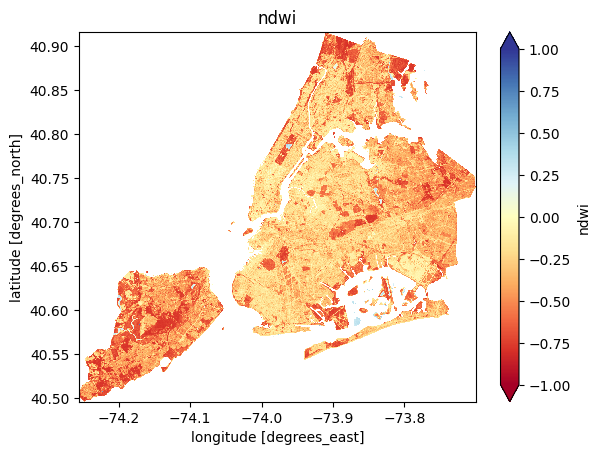

In [77]:
ndwi.plot(vmin=-1, vmax=1, cmap='RdYlBu')
plt.title("ndwi")

Text(0.5, 1.0, 'ndmi')

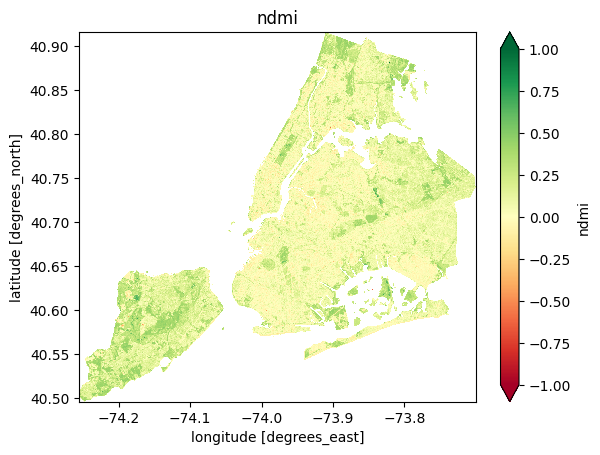

In [74]:
ndmi.plot(vmin=-1, vmax=1, cmap='RdYlGn')
plt.title("ndmi")

Text(0.5, 1.0, 'mndwi')

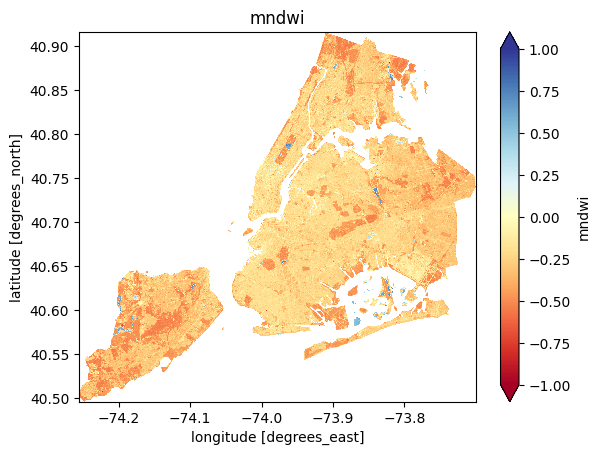

In [73]:
mndwi.plot(vmin=-1, vmax=1, cmap='RdYlBu')
plt.title("mndwi")

Text(0.5, 1.0, 'ndvi')

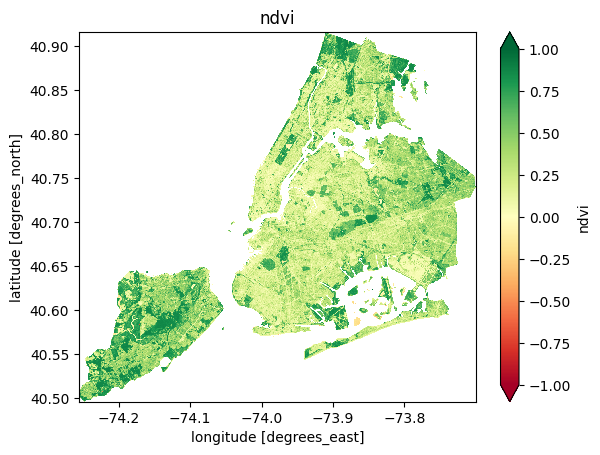

In [71]:
ndvi.plot(vmin=-1, vmax=1, cmap='RdYlGn')
plt.title("ndvi")

In [80]:

max_vwi = np.maximum(ndvi, ndwi) 

Text(0.5, 1.0, 'max_vwi')

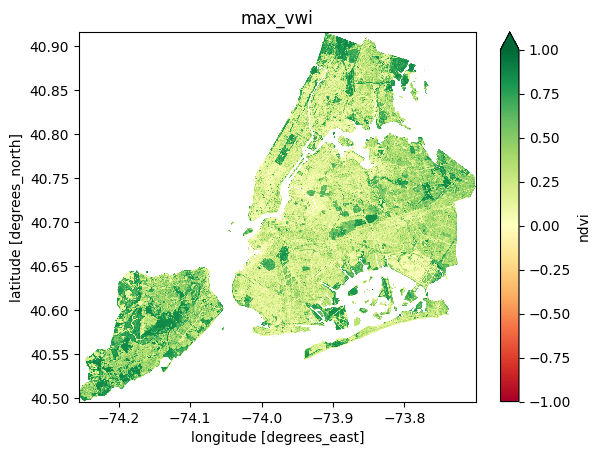

In [81]:
max_vwi.plot(vmin=-1, vmax=1, cmap='RdYlGn')
plt.title("max_vwi")

In [ ]:
# https://par.nsf.gov/servlets/purl/10396679